# Low-Stress Network Fragmentation Score (`connectivity_lts`)

RideScore's existing models score each street segment using only that segment's own
attributes. This notebook asks an extra question of every segment that looks
**Low-stress**: is it part of a large, connected Low-stress network, or is it an isolated island?

Snapshot-only: no crash data and no existing pipeline scores. See
`fragmentation_score_plan.md` at the repo root for the full plan. The notebook is built
one step at a time; each step has a short explanation and then small, self-contained cells.

## Step 0 — Environment and data load

Goal: confirm the libraries import, find the snapshot files, load them, and check that
the Parquet and GeoJSON versions hold the same data. Nothing else yet.

In [1]:
# Libraries used throughout the notebook
from pathlib import Path

import geopandas as gpd
import matplotlib
import networkx as nx
import pandas as pd

print("geopandas ", gpd.__version__)
print("networkx  ", nx.__version__)
print("matplotlib", matplotlib.__version__)
print("pandas    ", pd.__version__)

geopandas  1.1.4
networkx   3.7
matplotlib 3.11.1
pandas     3.0.5


### Locate the snapshot files

This notebook lives at `notebooks/low-stress-fragmentation/`, so the data folder
(`ridescore-data`, a sibling of the repo) is three levels up, not one.

In [2]:
# Settings used by later steps
SNAPSHOT_DATE = "2026-09-29"
DATA_DIR = Path("../../../ridescore-data")
PARQUET_PATH = DATA_DIR / f"ridescore_dc_basemap_{SNAPSHOT_DATE}.parquet"
GEOJSON_PATH = DATA_DIR / f"ridescore_dc_basemap_{SNAPSHOT_DATE}.geojson"

# Fail loudly (with the resolved absolute path) if the folder is wrong,
# rather than silently loading stale data
for path in (PARQUET_PATH, GEOJSON_PATH):
    print(f"{path.resolve()}  exists={path.exists()}")
    assert path.exists(), f"Snapshot file not found: {path.resolve()}"


C:\Users\noeti\ridescore-data\ridescore_dc_basemap_2026-09-29.parquet  exists=True
C:\Users\noeti\ridescore-data\ridescore_dc_basemap_2026-09-29.geojson  exists=True


### Load the Parquet snapshot

The Parquet file is the main table (fast to load). Geometry is stored in the file as
well, so it comes back as a GeoDataFrame.

In [3]:
# geopandas reads Parquet files with geometry
segments = gpd.read_parquet(PARQUET_PATH)

print("type:", type(segments).__name__)
print("shape:", segments.shape)
print("CRS: EPSG", segments.crs.to_epsg())
print("geometry types:", segments.geometry.geom_type.value_counts().to_dict())

type: GeoDataFrame
shape: (28978, 135)
CRS: EPSG 4326
geometry types: {'LineString': 28978}


### Load the GeoJSON snapshot

Same data in a different format. The file is large (~120 MB), so this cell takes a moment.

In [4]:
# Load the same snapshot from GeoJSON, for the cross-check below
segments_geojson = gpd.read_file(GEOJSON_PATH)

print("shape:", segments_geojson.shape)
print("CRS: EPSG", segments_geojson.crs.to_epsg())

shape: (28978, 135)
CRS: EPSG 4326


### Cross-check: do the two formats agree?

Before relying on either file, confirm they have the same rows, the same columns, and the
same segment IDs. Segment identity is `(osm_u, osm_v, osm_key)`, and it must be unique.

In [5]:
ID_COLS = ["osm_u", "osm_v", "osm_key"]

# Same shape and same set of columns?
print("same shape:  ", segments.shape == segments_geojson.shape)
print("same columns:", set(segments.columns) == set(segments_geojson.columns))

# IDs must be unique within each file
print("duplicate IDs (parquet):", segments.duplicated(ID_COLS).sum())
print("duplicate IDs (geojson):", segments_geojson.duplicated(ID_COLS).sum())

# Same set of IDs in both files?
ids_parquet = set(map(tuple, segments[ID_COLS].to_numpy()))
ids_geojson = set(map(tuple, segments_geojson[ID_COLS].to_numpy()))
print("same ID set: ", ids_parquet == ids_geojson)

same shape:   True
same columns: True
duplicate IDs (parquet): 0
duplicate IDs (geojson): 0
same ID set:  True


### Column list

All columns in the snapshot (`osm_*` from OpenStreetMap, `dc_*` from DDOT, plus the join's
`match_*` columns).

In [6]:
print(f"{segments.shape[0]:,} rows x {segments.shape[1]} columns")
print()
for i in range(0, len(segments.columns), 4):
    print("  ".join(f"{c:<32}" for c in segments.columns[i:i + 4]))

28,978 rows x 135 columns

osm_id                            osm_u                             osm_v                             osm_key                         
osm_highway                       osm_name                          osm_access                        osm_bicycle                     
osm_oneway                        osm_oneway_bicycle                osm_maxspeed                      osm_lanes                       
osm_lanes_forward                 osm_lanes_backward                osm_cycleway                      osm_cycleway_left               
osm_cycleway_left_buffer          osm_cycleway_left_oneway          osm_cycleway_right                osm_cycleway_right_buffer       
osm_cycleway_right_oneway         osm_cycleway_both                 osm_cycleway_both_buffer          osm_cycleway_buffer             
osm_cycleway_width                osm_parking_left                  osm_parking_right                 osm_parking_both                
osm_parking_lane_left       

## Step 1 — Missingness audit

Goal: before merging DDOT and OpenStreetMap attributes (Step 2), measure how much is actually
missing in each source. We audit three attribute pairs: **speed**, **lanes**, and **bike facility**.

Two things to keep in mind for the README:
- A null in a bike-facility column may mean "not tagged", not "confirmed no facility". We will have to treat it as "no facility" anyway, so this is an assumption.
- `osm_maxspeed` and `osm_lanes` are stored as text, so they need parsing before any arithmetic.

### 1a. Null rate of every source column

The columns that feed each attribute, with their dtype and percent missing. The bike-facility
columns are the type columns only (not their `_buffer`, `_width` or `_oneway` detail columns).

In [7]:
# Columns that feed each attribute (DDOT first, then OSM)
SPEED_COLS = ["dc_SPEEDLIMITS_OB", "osm_maxspeed"]
LANES_COLS = ["dc_TOTALTRAVELLANES", "osm_lanes"]
OSM_BIKE_COLS = ["osm_cycleway", "osm_cycleway_left", "osm_cycleway_right", "osm_cycleway_both"]
DC_BIKE_COLS = [c for c in segments.columns if c.startswith("dc_BIKELANE_")]

# One small table: dtype and % null for each column
audit_cols = SPEED_COLS + LANES_COLS + OSM_BIKE_COLS + DC_BIKE_COLS
null_audit = pd.DataFrame({
    "dtype": segments[audit_cols].dtypes.astype(str),
    "null_pct": (segments[audit_cols].isna().mean() * 100).round(1),
})
null_audit

,dtype,null_pct
dc_SPEEDLIMITS_OB,float64,20.1
osm_maxspeed,str,70.9
dc_TOTALTRAVELLANES,float64,4.8
osm_lanes,str,53.2
osm_cycleway,str,90.3
osm_cycleway_left,str,95.1
osm_cycleway_right,str,90.9
osm_cycleway_both,str,95.0
dc_BIKELANE_PARKINGLANE_ADJACENT,str,92.1
dc_BIKELANE_THROUGHLANE_ADJACENT,str,91.0


### 1b. Join quality and how much the fallback will fill

`match_status` says how well each OSM segment matched a DDOT segment (`none` means the `dc_*`
columns are empty). Then, for each attribute, we count the segments whose value comes from
DDOT only, OSM only, both, or neither. "Neither" is what stays missing even after the Step 2 fallback.

In [8]:
# How well did OSM segments match DDOT segments?
match_counts = segments["match_status"].value_counts()
print(pd.DataFrame({"segments": match_counts, "pct": (match_counts / len(segments) * 100).round(1)}))
print()

# For one attribute: how many segments have a value in DDOT only, OSM only, both, or neither?
def source_coverage(dc_has, osm_has):
    return pd.Series({
        "both sources": (dc_has & osm_has).sum(),
        "DDOT only": (dc_has & ~osm_has).sum(),
        "OSM only (fallback fills)": (~dc_has & osm_has).sum(),
        "neither (stays missing)": (~dc_has & ~osm_has).sum(),
    })

# For bike facility, "has a value" means any of the facility columns is non-null
dc_bike_tagged = segments[DC_BIKE_COLS].notna().any(axis=1)
osm_bike_tagged = segments[OSM_BIKE_COLS].notna().any(axis=1)

coverage = pd.DataFrame({
    "speed": source_coverage(segments["dc_SPEEDLIMITS_OB"].notna(), segments["osm_maxspeed"].notna()),
    "lanes": source_coverage(segments["dc_TOTALTRAVELLANES"].notna(), segments["osm_lanes"].notna()),
    "bike facility": source_coverage(dc_bike_tagged, osm_bike_tagged),
})
coverage_pct = (coverage / len(segments) * 100).round(1)
pd.concat([coverage, coverage_pct.add_suffix(" %")], axis=1)

              segments   pct
match_status                
good             26974  93.1
none              1399   4.8
weak               605   2.1



,speed,lanes,bike facility,speed %,lanes %,bike facility %
both sources,6969,13255,3893,24.0,45.7,13.4
DDOT only,16174,14324,1051,55.8,49.4,3.6
OSM only (fallback fills),1450,297,3088,5.0,1.0,10.7
neither (stays missing),4385,1102,20946,15.1,3.8,72.3


### 1c. What do the raw values look like?

Which text values fail to parse as numbers, and which values the bike-facility columns hold.
Step 2 needs this to decide what counts as "a facility is present" (for example, an OSM value of `no` is
non-null but means *no* facility).

In [9]:
# osm_maxspeed looks like "25 mph" and osm_lanes like "2" (or "2;3"): which values fail to parse?
speed_text = segments["osm_maxspeed"].dropna()
speed_parsed = pd.to_numeric(speed_text.str.replace(" mph", "", regex=False), errors="coerce")
print("osm_maxspeed values that don't parse as '<number> mph':", speed_parsed.isna().sum())
print(speed_text[speed_parsed.isna()].value_counts().head(10).to_string())
print()

lanes_text = segments["osm_lanes"].dropna()
lanes_parsed = pd.to_numeric(lanes_text, errors="coerce")
print("osm_lanes values that don't parse as a number:", lanes_parsed.isna().sum())
print(lanes_text[lanes_parsed.isna()].value_counts().head(10).to_string())
print()

# Bike-facility columns: the distinct values each one holds (nulls excluded)
for col in OSM_BIKE_COLS + DC_BIKE_COLS:
    print(f"{col}: {segments[col].value_counts().to_dict()}")

osm_maxspeed values that don't parse as '<number> mph': 0
Series([], )

osm_lanes values that don't parse as a number: 0
Series([], )

osm_cycleway: {'crossing': 1513, 'shared_lane': 617, 'separate': 410, 'lane': 180, 'no': 33, 'share_busway': 27, 'traffic_island': 17, 'track': 5, 'shoulder': 4, 'sidewalk': 2, 'buffered_lane': 1}
osm_cycleway_left: {'no': 611, 'separate': 432, 'lane': 149, 'shared_lane': 100, 'opposite_lane': 78, 'track': 28, 'share_busway': 20}
osm_cycleway_right: {'lane': 1146, 'no': 544, 'separate': 426, 'shared_lane': 368, 'track': 71, 'share_busway': 71, 'shoulder': 2, 'opposite_lane': 2}
osm_cycleway_both: {'no': 781, 'lane': 518, 'shared_lane': 72, 'separate': 44, 'track': 14, 'share_busway': 13}
dc_BIKELANE_PARKINGLANE_ADJACENT: {'IB': 932, 'BD': 878, 'OB': 489}
dc_BIKELANE_THROUGHLANE_ADJACENT: {'BD': 1171, 'IB': 1083, 'OB': 362}
dc_BIKELANE_POCKETLANE_ADJACENT: {'OB': 49, 'IB': 37}
dc_BIKELANE_CONTRAFLOW: {'IB': 198, 'OB': 157}
dc_BIKELANE_CONVENTIONAL: {'IB'

## Step 2 — Fallback-merged attributes

Goal: build three clean columns, `speed_mph`, `lanes_total` and `has_bike_facility`, by combining DDOT and OSM.

- **Speed and lanes:** DDOT first, OSM as the fallback when DDOT is null.
- **Bike facility:** present if *any* source indicates one (DDOT or OSM), so the order doesn't matter.
- Formats are normalized (text to numbers) **before** merging, so we never mix types.

Assumption for the README: a segment with no facility indicator in any source is treated as having **no** facility.

### 2a. Speed and lanes

Convert OSM's text values to numbers, then fill DDOT's gaps from OSM. We also record which source each
value came from, so Step 3 and the README can count how much came from the fallback.
A DDOT speed of 0 mph is not a real limit, so it's treated as missing. A lane count of 0 is kept: DDOT uses it for
paths with no car lanes.

In [10]:
import numpy as np

# Normalize OSM text to numbers first: "25 mph" -> 25.0 and "2" -> 2.0
osm_speed = pd.to_numeric(segments["osm_maxspeed"].str.replace(" mph", "", regex=False), errors="coerce")
osm_lanes = pd.to_numeric(segments["osm_lanes"], errors="coerce")

# DDOT values (already numeric); a 0 mph limit is not real, so treat it as missing
dc_speed = segments["dc_SPEEDLIMITS_OB"].where(segments["dc_SPEEDLIMITS_OB"] > 0)
dc_lanes = segments["dc_TOTALTRAVELLANES"]

# Merge: use DDOT, and fill any DDOT gaps from OSM
segments["speed_mph"] = dc_speed.combine_first(osm_speed)
segments["lanes_total"] = dc_lanes.combine_first(osm_lanes)

# Record where each value came from (DDOT, OSM, or still missing)
segments["speed_source"] = np.where(dc_speed.notna(), "DDOT", np.where(osm_speed.notna(), "OSM", "missing"))
segments["lanes_source"] = np.where(dc_lanes.notna(), "DDOT", np.where(osm_lanes.notna(), "OSM", "missing"))

print(segments["speed_source"].value_counts().to_string())
print()
print(segments["lanes_source"].value_counts().to_string())

speed_source
DDOT       23137
missing     4390
OSM         1451

lanes_source
DDOT       27579
missing     1102
OSM          297


### 2b. Bike facility

A segment has a bike facility if **any** of these is true:
- **DDOT:** any `dc_BIKELANE_*` column is non-null (the codes `IB`, `OB`, `BD` all mean a lane exists).
- **OSM:** a `cycleway*` column holds `lane`, `track`, `buffered_lane` or `opposite_lane`.
- **Off-street path:** the segment *is* a bike path (`highway` is `cycleway`, `path` or `footway`; the snapshot only keeps bike-designated paths).

Values that are *not* counted: `no`, `shared_lane` and `share_busway` (no dedicated space), `separate` (the lane is a separate
way, not this street), and junction artifacts (`crossing`, `traffic_island`, `sidewalk`, `shoulder`).
`OSM_BIKE_COLS` and `DC_BIKE_COLS` come from Step 1.

In [11]:
# OSM cycleway values that mean a dedicated facility is present
OSM_PRESENT_VALUES = {"lane", "track", "buffered_lane", "opposite_lane"}
# OSM street types that are themselves a bike path
OFFSTREET_PATH_TYPES = {"cycleway", "path", "footway"}

# One True/False column per source
osm_facility = segments[OSM_BIKE_COLS].isin(OSM_PRESENT_VALUES).any(axis=1)
dc_facility = segments[DC_BIKE_COLS].notna().any(axis=1)
is_offstreet_path = segments["osm_highway"].isin(OFFSTREET_PATH_TYPES)

# Present if any source says so; null/untagged everywhere means no facility
segments["has_bike_facility"] = osm_facility | dc_facility | is_offstreet_path

print("OSM says facility:      ", osm_facility.sum())
print("DDOT says facility:     ", dc_facility.sum())
print("Off-street path:        ", is_offstreet_path.sum())
print("has_bike_facility total:", segments["has_bike_facility"].sum())

# Conflicts: OSM explicitly says "no" but DDOT says a facility exists (resolved in favor of "present")
osm_says_no = (segments[OSM_BIKE_COLS] == "no").any(axis=1) & ~osm_facility
print("OSM 'no' but DDOT facility:", (osm_says_no & dc_facility).sum())

OSM says facility:       2086
DDOT says facility:      4944
Off-street path:         3426
has_bike_facility total: 6817
OSM 'no' but DDOT facility: 321


### 2c. Check the merged columns

Null counts and value ranges for the new columns, how often DDOT and OSM disagree when both have a value,
and facility rates by street type as a plausibility check (trails should be ~100%, arterials much lower).

In [12]:
# Merged columns: how many are still missing, and what range do they cover?
merged = segments[["speed_mph", "lanes_total", "has_bike_facility"]]
print("still missing:\n", merged.isna().sum().to_string(), sep="")
print()
print(merged[["speed_mph", "lanes_total"]].describe().round(1).to_string())
print()

# Where both sources have a value, how often do they differ? (DDOT wins in the merge)
both_speed = dc_speed.notna() & osm_speed.notna()
both_lanes = dc_lanes.notna() & osm_lanes.notna()
print(f"speed differs: {(dc_speed != osm_speed)[both_speed].sum()} of {both_speed.sum()}")
print(f"lanes differ:  {(dc_lanes != osm_lanes)[both_lanes].sum()} of {both_lanes.sum()}")
print()

# Facility rate by OSM street type: a plausibility check
facility_by_type = segments.groupby("osm_highway")["has_bike_facility"].agg(["size", "mean"])
facility_by_type.columns = ["segments", "share_with_facility"]
facility_by_type.round(2).sort_values("segments", ascending=False)

still missing:
speed_mph            4390
lanes_total          1102
has_bike_facility       0

       speed_mph  lanes_total
count    24588.0      27876.0
mean        21.8          2.3
std          3.5          1.3
min          5.0          0.0
25%         20.0          2.0
50%         20.0          2.0
75%         25.0          2.0
max         45.0         10.0

speed differs: 2679 of 6968
lanes differ:  5572 of 13255



,segments,share_with_facility
osm_highway,,
residential,13259,0.03
tertiary,3795,0.34
primary,3462,0.15
secondary,3268,0.34
cycleway,3134,1.00
trunk,591,0.04
unclassified,588,0.03
primary_link,308,0.07
path,175,1.00


## Step 3 — Stress classification (`base_stress_class`)

Goal: classify every segment as **Low**, **Medium**, **High** or **Unknown** using only its own attributes
(no connectivity yet). Rules are applied in this order, and the first match wins:

1. **Off-street path** (`cycleway`, `path`, `footway`) → **Low**. There is no car traffic, so speed and lanes don't apply.
2. **High:** `speed_mph >= 35`, or `lanes_total >= 3` with no bike facility.
3. **Low:** `speed_mph <= 25` with a bike facility, **or** `speed_mph <= 20` with `lanes_total <= 2` and no facility.
4. **Unknown:** speed or lanes is missing and rules 1–3 could not decide.
5. **Medium:** everything else.

Rule 3 is a relaxed version of the plan's draft (`speed <= 25 AND has_bike_facility`). The strict draft would label
almost every residential street Medium (only 3% have a facility), which is stricter than standard LTS. But allowing
**every** quiet 1–2 lane street up to 25 mph made Low about 74% of the network and Medium nearly empty. So a facility
earns the 25 mph limit, and a street **without** one must be 20 mph or slower (the limit DC posts on most residential streets
and the repo's own LTS rule for no-facility streets). Three versions are compared below. `Unknown` stays in this column and
becomes `Medium` only in the final column (Step 7).

Comparisons with a missing value are False in pandas, so a missing speed or lane count can never silently
pass as "Low" or "High". It lands in `Unknown` unless the other attributes already decide the class.

### 3a. The classification function

Thresholds are named constants at the top so they are easy to find and change. The function takes the speed limit allowed
for a Low street *without* a facility (or `None` if a facility is required), so we can compare versions.

In [17]:
# Thresholds (first draft; tuned by eye, not validated)
LOW_MAX_SPEED_WITH_FACILITY = 25   # Low with a bike facility: speed at or below this
LOW_MAX_SPEED_NO_FACILITY = 20     # Low without a facility: speed at or below this (and few lanes)
LOW_MAX_LANES = 2                  # Low without a facility needs this many lanes or fewer
HIGH_MIN_SPEED_MPH = 35            # High at or above this speed
HIGH_MIN_LANES = 3                 # High with this many lanes and no facility


def classify_stress(df, max_speed_no_facility=LOW_MAX_SPEED_NO_FACILITY):
    # Return a Series of Low / Medium / High / Unknown for each segment.
    # max_speed_no_facility=None means a facility is required for Low (the plan's strict draft).
    speed, lanes, facility = df["speed_mph"], df["lanes_total"], df["has_bike_facility"]
    is_path = df["osm_highway"].isin(OFFSTREET_PATH_TYPES)

    # Each test is False (not an error) when its inputs are missing
    is_high = (speed >= HIGH_MIN_SPEED_MPH) | ((lanes >= HIGH_MIN_LANES) & ~facility)
    is_low = (speed <= LOW_MAX_SPEED_WITH_FACILITY) & facility
    if max_speed_no_facility is not None:
        is_low = is_low | ((speed <= max_speed_no_facility) & (lanes <= LOW_MAX_LANES))
    has_gap = speed.isna() | lanes.isna()

    # First match wins: path, then High, then Low, then Unknown, else Medium
    result = pd.Series("Medium", index=df.index)
    result[has_gap] = "Unknown"
    result[is_low] = "Low"
    result[is_high] = "High"
    result[is_path] = "Low"
    return result

### 3b. Compare three versions, then pick one

Same function, three settings: the plan's **strict** draft (facility required), a **single 25 mph** limit for every
street, and the **chosen** rule (25 mph with a facility, 20 mph without). The README will say which version was used and why.

In [18]:
# Run the three versions and compare the distributions
strict = classify_stress(df=segments, max_speed_no_facility=None)
single_25 = classify_stress(df=segments, max_speed_no_facility=25)
chosen = classify_stress(df=segments)   # 20 mph without a facility

order = ["Low", "Medium", "High", "Unknown"]
comparison = pd.DataFrame({
    "strict": strict.value_counts(),
    "single 25 mph": single_25.value_counts(),
    "chosen": chosen.value_counts(),
}).reindex(order)
pct = (comparison / len(segments) * 100).round(1).add_suffix(" %")
display(pd.concat([comparison, pct], axis=1))

# Keep the chosen rule as the model's base classification
segments["base_stress_class"] = chosen

,strict,single 25 mph,chosen,strict %,single 25 mph %,chosen %
Low,6239,21331,18498,21.5,73.6,63.8
Medium,15439,347,3180,53.3,1.2,11.0
High,4645,4645,4645,16.0,16.0,16.0
Unknown,2655,2655,2655,9.2,9.2,9.2


### 3c. Checks

Where `Unknown` comes from, how the classes spread across street types, and a few real example rows to spot-check against the rules.

In [19]:
# Why are segments Unknown? (what is missing)
unknown = segments[segments["base_stress_class"] == "Unknown"]
reason = pd.Series("speed and lanes missing", index=unknown.index)
reason[unknown["speed_mph"].isna() & unknown["lanes_total"].notna()] = "speed missing only"
reason[unknown["speed_mph"].notna() & unknown["lanes_total"].isna()] = "lanes missing only"
print(f"Unknown segments: {len(unknown)}")
print(reason.value_counts().to_string())
print()

# Class mix by street type (rows add to 100%)
by_type = pd.crosstab(segments["osm_highway"], segments["base_stress_class"], normalize="index")
display((by_type[order] * 100).round(0).assign(segments=segments["osm_highway"].value_counts()))

Unknown segments: 2655
speed missing only         2198
speed and lanes missing     413
lanes missing only           44



base_stress_class,Low,Medium,High,Unknown,segments
osm_highway,,,,,
cycleway,100.0,0.0,0.0,0.0,3134
footway,100.0,0.0,0.0,0.0,117
living_street,26.0,9.0,1.0,64.0,74
path,100.0,0.0,0.0,0.0,175
primary,18.0,8.0,71.0,4.0,3462
primary_link,13.0,12.0,11.0,64.0,308
residential,81.0,9.0,1.0,10.0,13259
secondary,37.0,22.0,32.0,9.0,3268
secondary_link,26.0,11.0,4.0,59.0,80


In [20]:
# A few example rows per class, to check against the rules by eye
show_cols = ["osm_name", "osm_highway", "speed_mph", "lanes_total", "has_bike_facility", "base_stress_class"]
for cls in order:
    print(f"--- {cls} ---")
    print(segments[segments["base_stress_class"] == cls][show_cols].sample(4, random_state=1).to_string(index=False))

--- Low ---
             osm_name  osm_highway  speed_mph  lanes_total  has_bike_facility base_stress_class
                  NaN unclassified       20.0          2.0              False               Low
 19th Place Northeast  residential       20.0          2.0              False               Low
Half Street Southwest  residential       20.0          1.0              False               Low
                  NaN     cycleway       25.0          1.0               True               Low
--- Medium ---
                 osm_name osm_highway  speed_mph  lanes_total  has_bike_facility base_stress_class
    31st Street Northeast residential       25.0          2.0              False            Medium
  Newton Street Northeast residential       25.0          2.0              False            Medium
Trinidad Avenue Northeast residential       25.0          1.0              False            Medium
     Riggs Road Northeast     primary       25.0          0.0              False            Mediu

## Step 4 — Directed graph construction

Goal: turn the segment table into **directed edges** between OSM nodes (`osm_u` and `osm_v` are node IDs), respecting one-way streets.

- Every segment gives one edge in its allowed direction.
- It also gives the reverse edge if the street is two-way, **or** one-way with a bicycle contraflow exemption.
- Each edge keeps its segment ID and `base_stress_class`. The graph is kept as an **edge table** and only collapsed into a `DiGraph` in Step 5, *after* filtering to Low.
  A plain `DiGraph` merges parallel edges, and two parallel segments (a street and its cycle track) can have different classes, so collapsing before classifying would lose one of them.

**Important caveat found while building this step:** the plan assumed a one-way street's legal direction is `u → v`. In this snapshot it is **not**
(see 4a and 4d). The extract merged the two directions of each street into one row, and `osm_u`/`osm_v` are in arbitrary order for one-way streets.
The legal direction is carried by the **geometry** (first point to last point), so the edges below follow the geometry.

### 4a. How are segments stored?

Three things to confirm before building anything:
1. **A two-way street is one row**, not two (one per direction). If rows came in reverse pairs, we would double-count later.
2. **Which node does each geometry start at?** For every segment we compare its first and last point with the points where its neighbors
   meet at node `u` and node `v`. Result: `u_to_v` (geometry starts at `u`), `v_to_u`, `loop` (`u == v`), or `ambiguous` (no evidence either way).
3. **Is `osm_u`/`osm_v` order related to one-way direction?** If `u → v` were the legal direction, every one-way segment would be `u_to_v`.

In [21]:
import shapely
from collections import Counter, defaultdict

# 1. Reverse twins: a row (u, v, key) with another row (v, u, key). Self-loops (u == v) are their own twin, so exclude them.
ids = list(zip(segments["osm_u"], segments["osm_v"], segments["osm_key"]))
segment_ids = set(ids)
has_twin = pd.Series([(v, u, k) in segment_ids for u, v, k in ids], index=segments.index)
is_self_loop = segments["osm_u"] == segments["osm_v"]
print("segments with a reverse twin (excluding self-loops):", (has_twin & ~is_self_loop).sum())
print("self-loops (u == v):", is_self_loop.sum())
print("segments sharing their (u, v) with another segment (parallel):", segments.duplicated(["osm_u", "osm_v"], keep=False).sum())

# 2. Geometry end points, rounded to about 1 m so touching segments agree
first_xy = shapely.get_coordinates(shapely.get_point(segments.geometry.values, 0))
last_xy = shapely.get_coordinates(shapely.get_point(segments.geometry.values, -1))
first_pt = [tuple(p) for p in np.round(first_xy, 5)]
last_pt = [tuple(p) for p in np.round(last_xy, 5)]

# For each node, count how often each coordinate appears as a segment end among the segments touching it.
# The node's real location shows up in every touching segment, so it gets the highest count.
ends_at_node = defaultdict(Counter)
for u, v, a, b in zip(segments["osm_u"], segments["osm_v"], first_pt, last_pt):
    for node in (u, v):
        ends_at_node[node][a] += 1
        ends_at_node[node][b] += 1

def geometry_direction(u, v, a, b):
    # Does the geometry start at u (u_to_v) or at v (v_to_u)? Compare the evidence for each reading
    if u == v:
        return "loop"
    starts_at_u = ends_at_node[u][a] + ends_at_node[v][b]
    starts_at_v = ends_at_node[u][b] + ends_at_node[v][a]
    if starts_at_u == starts_at_v:
        return "ambiguous"
    return "u_to_v" if starts_at_u > starts_at_v else "v_to_u"

segments["geometry_runs"] = [geometry_direction(u, v, a, b)
                             for u, v, a, b in zip(segments["osm_u"], segments["osm_v"], first_pt, last_pt)]

# 3. If u -> v were always the legal direction, the one-way column would be all u_to_v
pd.crosstab(segments["geometry_runs"], segments["osm_oneway"], margins=True)

segments with a reverse twin (excluding self-loops): 0
self-loops (u == v): 82
segments sharing their (u, v) with another segment (parallel): 188


osm_oneway,False,True,All
geometry_runs,,,
ambiguous,42,3,45
loop,49,33,82
u_to_v,16,5286,5302
v_to_u,18747,4802,23549
All,18854,10124,28978


### 4b. Contraflow exemptions

A one-way street normally lets bikes go only in its legal direction. We add the reverse edge when any of these signals says bikes may ride against traffic:
- `osm_oneway_bicycle == "no"` (OSM: the one-way doesn't apply to bikes)
- `dc_BIKELANE_CONTRAFLOW` is set (DDOT: a contraflow bike lane)
- an OSM cycleway value of `opposite_lane`
- `osm_cycleway_left_oneway == "-1"` (a left-side lane running against the street)

An explicit `osm_oneway_bicycle == "yes"` (bikes are restricted too) overrides the other signals. `osm_oneway` has no nulls, so no default is needed for unknown one-way status.
One-way segments whose geometry direction is `ambiguous` (a handful) are treated as two-way, since we can't tell which way is legal.
As a cross-check we also compare with DDOT's `dc_SUMMARYDIRECTION` (`BD` = both directions; `IB`/`OB` = one-way), without using it to change anything.

In [22]:
one_way = segments["osm_oneway"]

# One True/False column per contraflow signal
signals = pd.DataFrame({
    "OSM oneway:bicycle = no": segments["osm_oneway_bicycle"] == "no",
    "DDOT contraflow lane": segments["dc_BIKELANE_CONTRAFLOW"].notna(),
    "OSM opposite_lane": segments[OSM_BIKE_COLS].isin(["opposite_lane"]).any(axis=1),
    "OSM left cycleway oneway = -1": segments["osm_cycleway_left_oneway"] == "-1",
})
bikes_restricted = segments["osm_oneway_bicycle"] == "yes"   # OSM says bikes must obey the one-way too

# Only one-way streets matter: how many have each signal?
print(f"one-way segments: {one_way.sum()}")
print(signals[one_way].sum().to_string())
has_signal = signals.any(axis=1)
print("\nany signal (one-way segments):", (has_signal & one_way).sum())
print("signal but OSM says bikes restricted:", (has_signal & bikes_restricted & one_way).sum())

# A one-way segment lets bikes travel both ways only with an unrestricted contraflow signal
contraflow_exempt = one_way & has_signal & ~bikes_restricted
unknown_direction = one_way & (segments["geometry_runs"] == "ambiguous")
segments["allows_reverse"] = ~one_way | contraflow_exempt | unknown_direction
print("\nsegments with both directions:", segments["allows_reverse"].sum(), "| one direction only:", (~segments["allows_reverse"]).sum())

# Cross-check (not used): OSM one-way flag vs DDOT's direction code
print()
print(pd.crosstab(segments["dc_SUMMARYDIRECTION"].fillna("missing"), segments["osm_oneway"], rownames=["DDOT direction"], colnames=["osm_oneway"]))

one-way segments: 10124
OSM oneway:bicycle = no          180
DDOT contraflow lane             330
OSM opposite_lane                 79
OSM left cycleway oneway = -1     60

any signal (one-way segments): 389
signal but OSM says bikes restricted: 8

segments with both directions: 19238 | one direction only: 9740

osm_oneway      False  True 
DDOT direction              
??                733    170
BD              16724   4406
IB                263   2283
OB                390   2610
missing           744    655


### 4c. Build the directed edges

One row per directed edge, keyed by the segment it came from. The main edge goes from the node where the geometry **starts** to the node where it **ends**
(the legal direction for one-way streets; for two-way streets either direction is fine because the reverse edge is added too).
A segment with both directions allowed gets a second, reversed edge.
We also load the full network into a `DiGraph` just for node and edge counts. It is **not** used for classification, because parallel edges collapse there.

In [23]:
# Which node does each segment's geometry start at? Usually u, but v for the "v_to_u" segments
runs_backwards = segments["geometry_runs"] == "v_to_u"
start_node = segments["osm_v"].where(runs_backwards, segments["osm_u"])
end_node = segments["osm_u"].where(runs_backwards, segments["osm_v"])

# Main edge for every segment: geometry start -> geometry end
edge_cols = ["osm_u", "osm_v", "osm_key", "base_stress_class"]
forward = segments[edge_cols].assign(src=start_node, dst=end_node, direction="forward")

# Reverse edge where bikes may travel both ways; a self-loop's reverse is the same edge, so skip it
reverse_mask = segments["allows_reverse"] & ~is_self_loop
reverse = segments.loc[reverse_mask, edge_cols].assign(
    src=end_node[reverse_mask], dst=start_node[reverse_mask], direction="reverse")

edges = pd.concat([forward, reverse], ignore_index=True)

# Every segment must appear once or twice, and the counts must add up
print("segments:", len(segments), "| reverse edges:", len(reverse), "| directed edges:", len(edges))
assert len(edges) == len(segments) + reverse_mask.sum()
assert edges.groupby(["osm_u", "osm_v", "osm_key"]).size().isin([1, 2]).all()

# Full network as a DiGraph, for counts only (parallel edges collapse here)
G_all = nx.from_pandas_edgelist(edges, "src", "dst", create_using=nx.DiGraph)
print("nodes:", G_all.number_of_nodes(), "| edges after collapsing parallels:", G_all.number_of_edges())

segments: 28978 | reverse edges: 19189 | directed edges: 48167
nodes: 21523 | edges after collapsing parallels: 48087


### 4d. Direction spot-check

Two questions: (1) does the **geometry** carry the legal direction, and (2) is that direction correct in the real world?

**(1)** Along a real one-way street, every segment should point the same way. We compare the compass heading of the geometry (first to last point)
with the heading of `u → v`. If geometry carries the direction, many streets will be consistent in the first and none in the second.

**(2)** Check against reality. The table lists named one-way streets whose segments all point the same way. **Pick one you know is one-way in DC and compare.**
There is also a test needing no street knowledge: on a divided road with right-hand traffic, the northbound carriageway is on the east side.
So North Capitol Street **NE** should point **N** and **NW** should point **S**.

In [24]:
# Compass heading (N/E/S/W) of the geometry, first point to last point
dx = (last_xy[:, 0] - first_xy[:, 0]) * np.cos(np.radians(38.9))   # shrink longitude to match latitude
dy = last_xy[:, 1] - first_xy[:, 1]
angle = np.degrees(np.arctan2(dx, dy)) % 360                         # 0 = north, 90 = east
segments["heading_geometry"] = np.array(["N", "E", "S", "W"])[((angle + 45) // 90).astype(int) % 4]

# Heading of u -> v: the same as the geometry, except flipped where the geometry runs v -> u
opposite = {"N": "S", "S": "N", "E": "W", "W": "E"}
segments["heading_u_to_v"] = [opposite[h] if r == "v_to_u" else h
                              for h, r in zip(segments["heading_geometry"], segments["geometry_runs"])]

# Named one-way streets with a known geometry direction (links excluded)
streets = segments[one_way & segments["osm_name"].notna() & ~segments["osm_highway"].str.endswith("_link")
                   & segments["geometry_runs"].isin(["u_to_v", "v_to_u"])]

def street_summary(heading_col):
    # Per street: segment count and the share pointing the most common way
    return streets.groupby("osm_name")[heading_col].agg(
        segments="size", main_heading=lambda s: s.value_counts().index[0],
        share=lambda s: s.value_counts(normalize=True).iloc[0].round(2))

by_geometry, by_u_to_v = street_summary("heading_geometry"), street_summary("heading_u_to_v")
for label, table in [("geometry heading", by_geometry), ("u -> v heading", by_u_to_v)]:
    long_streets = table[table["segments"] >= 20]
    print(f"{label}: {(long_streets['share'] >= 0.9).sum()} of {len(long_streets)} streets (20+ segments) are 90%+ consistent")

# Candidates to check against the real world
by_geometry[(by_geometry["segments"] >= 8) & (by_geometry["share"] >= 0.9)].sort_values("segments", ascending=False).head(15)

geometry heading: 30 of 111 streets (20+ segments) are 90%+ consistent
u -> v heading: 0 of 111 streets (20+ segments) are 90%+ consistent


,segments,main_heading,share
osm_name,,,
M Street Northwest,106,W,0.92
L Street Northwest,93,E,0.95
North Capitol Street Northwest,84,S,0.98
North Capitol Street Northeast,79,N,1.00
15th Street Northwest,62,N,0.97
R Street Northwest,59,W,1.00
East Capitol Street Southeast,54,E,0.96
East Capitol Street Northeast,53,W,0.96
T Street Northwest,51,E,0.94


In [25]:
# Check streets by name: which way do their one-way segments point? (edit the list to try others)
STREETS_TO_CHECK = ["15th Street Northwest", "North Capitol Street Northwest", "North Capitol Street Northeast"]

for name in STREETS_TO_CHECK:
    rows = segments[one_way & (segments["osm_name"] == name)]
    print(f"{name}: {len(rows)} one-way segments, geometry heading counts: {rows['heading_geometry'].value_counts().to_dict()}")

15th Street Northwest: 63 one-way segments, geometry heading counts: {'N': 61, 'S': 2}
North Capitol Street Northwest: 84 one-way segments, geometry heading counts: {'S': 82, 'N': 2}
North Capitol Street Northeast: 79 one-way segments, geometry heading counts: {'N': 79}


## Step 5 — Low-stress subgraph and strongly connected components

Goal: keep only the **Low** edges, find the **strongly connected components** (SCCs), and label every Low segment with its component.

A strongly connected component is a set of nodes where you can get from any node to any other **and back again** while following one-way directions.
That is the formal version of "this Low-stress street is part of a usable network".

- Components are found on **nodes**. A segment belongs to a component when both of its end nodes are in it.
- A **one-way** segment can have its two nodes in *different* components (there is no way back from its end to its start through Low streets).
  We call it a **cross-edge** and give it no component. It is not strongly connected, so it counts as isolated in Step 6.
- Parallel Low edges are collapsed into one graph edge here, which is safe because every edge in this graph is already Low.

### 5a. Build the Low graph and find the components

Filter the Step 4 edge table to Low edges, build a `DiGraph`, and run `nx.strongly_connected_components`.
Components are numbered from largest (0) to smallest, counting nodes.

In [26]:
# Only Low edges go into the graph (Medium, High and Unknown segments never become edges)
low_edges = edges[edges["base_stress_class"] == "Low"]
G_low = nx.from_pandas_edgelist(low_edges, "src", "dst", create_using=nx.DiGraph)
print("Low graph: nodes =", G_low.number_of_nodes(), "| directed edges =", G_low.number_of_edges())

# Strongly connected components: a list of node sets, largest first
components = sorted(nx.strongly_connected_components(G_low), key=len, reverse=True)
print("strongly connected components:", len(components))

# Component number for every node in the Low graph
node_component = {node: number for number, nodes in enumerate(components) for node in nodes}

Low graph: nodes = 16678 | directed edges = 32388
strongly connected components: 1723


### 5b. Label each Low segment

For each Low segment, look up the component of its two end nodes. If they match, that is the segment's component (`scc_id`).
If they differ, it is a cross-edge (`is_cross_edge = True`) and `scc_id` stays empty. Segments that are not Low get neither.

Each row of `segments` is one physical segment, so counting rows counts physical segments once. The two-edges-per-two-way-street
double-counting trap from the directed edge table doesn't apply here.

In [27]:
is_low = segments["base_stress_class"] == "Low"

# Component of each end node (only meaningful for Low segments)
scc_u = segments["osm_u"].map(node_component)
scc_v = segments["osm_v"].map(node_component)
assert scc_u[is_low].notna().all() and scc_v[is_low].notna().all(), "a Low segment's node is missing from the Low graph"

# Same component at both ends -> that component; different -> cross-edge
same_component = is_low & (scc_u == scc_v)
segments["scc_id"] = scc_u.where(same_component).astype("Int64")      # empty for non-Low segments and cross-edges
segments["is_cross_edge"] = is_low & (scc_u != scc_v)

print("Low segments:           ", is_low.sum())
print("  with a component:     ", same_component.sum())
print("  cross-edges (no SCC): ", segments["is_cross_edge"].sum())

Low segments:            18498
  with a component:      17163
  cross-edges (no SCC):  1335


### 5c. How big are the components?

Size of each component in **segments** (physical segments, not edges). Meters come in Step 6.
The size bands show how much of the Low network sits in one giant component versus small pieces. We use this to decide what "large" means in Step 6.
For comparison, the weakly connected version ignores one-way directions: the gap shows how much fragmentation comes from one-way streets.

In [28]:
# Segments per component, plus the cross-edges counted as one-segment "islands"
sizes = segments.loc[same_component].groupby("scc_id").size().sort_values(ascending=False)
print("largest component:", sizes.iloc[0], "segments =", round(sizes.iloc[0] / is_low.sum() * 100, 1), "% of Low segments")
print("components with a single segment:", (sizes == 1).sum())
print()

# Size bands: how many components, and how many Low segments, fall in each
bands = pd.cut(sizes, bins=[0, 1, 5, 20, 100, 1000, sizes.max()], labels=["1", "2-5", "6-20", "21-100", "101-1000", "1000+"])
band_table = pd.DataFrame({"components": bands.value_counts(), "segments": sizes.groupby(bands, observed=False).sum()})
band_table.loc["cross-edges"] = [segments["is_cross_edge"].sum(), segments["is_cross_edge"].sum()]
band_table["% of Low segments"] = (band_table["segments"] / is_low.sum() * 100).round(1)
display(band_table.loc[["1", "2-5", "6-20", "21-100", "101-1000", "1000+", "cross-edges"]])

# Weakly connected comparison (ignores one-way directions)
weak = sorted(nx.weakly_connected_components(G_low), key=len, reverse=True)
weak_of_node = {node: i for i, nodes in enumerate(weak) for node in nodes}
weak_sizes = segments.loc[is_low, "osm_u"].map(weak_of_node).value_counts()
print("weakly connected components:", len(weak), "| largest holds", round(weak_sizes.iloc[0] / is_low.sum() * 100, 1), "% of Low segments")

largest component: 13093 segments = 70.8 % of Low segments
components with a single segment: 173



,components,segments,% of Low segments
1,173,173,0.9
2-5,169,495,2.7
6-20,53,496,2.7
21-100,26,1220,6.6
101-1000,3,1686,9.1
1000+,1,13093,70.8
cross-edges,1335,1335,7.2


weakly connected components: 423 | largest holds 81.7 % of Low segments


### 5d. Map: mainland versus islands

A quick look at where the components are. The **largest** component is dark blue, other components are orange, cross-edges are red, and non-Low streets are light gray.
This is also the plausibility check for the direction logic in Step 4. If we had the directions backwards, the dense downtown grid would look shattered into many small pieces.

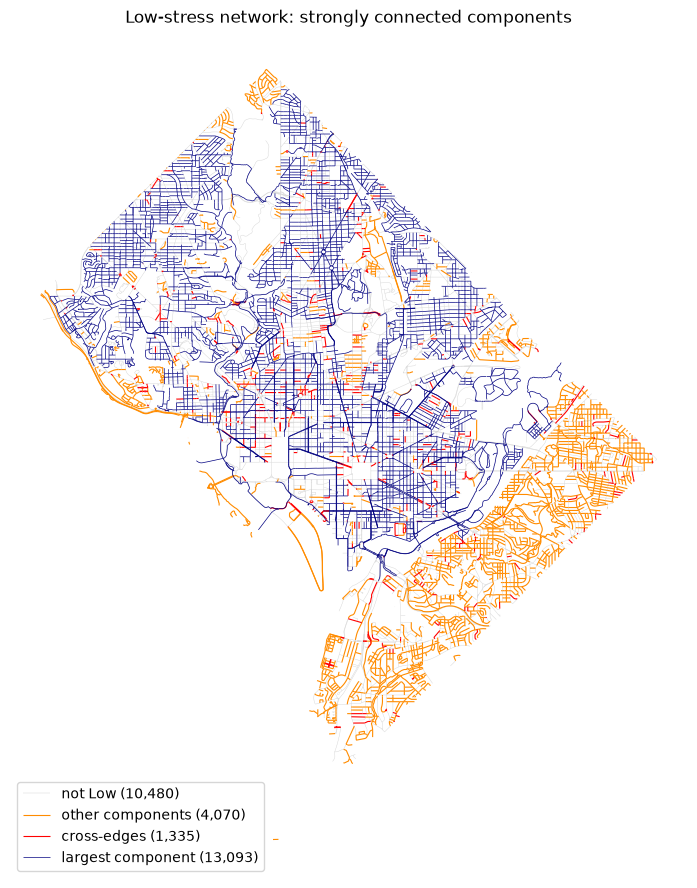

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))
low_with_component = segments[same_component]
layers = [
    (segments[~is_low], "lightgray", 0.3, "not Low"),
    (low_with_component[low_with_component["scc_id"] != 0], "darkorange", 0.8, "other components"),
    (segments[segments["is_cross_edge"]], "red", 0.8, "cross-edges"),
    (low_with_component[low_with_component["scc_id"] == 0], "navy", 0.5, "largest component"),
]
for data, color, width, label in layers:
    data.plot(ax=ax, color=color, linewidth=width, label=f"{label} ({len(data):,})")
ax.legend(loc="lower left")
ax.set_axis_off()
ax.set_title("Low-stress network: strongly connected components")
plt.show()

## Step 6 — Connectivity feature and island flag

Goal: give every Low segment the **size of its component** (in segments and in meters) and decide which segments count as **isolated**.

- `component_size_segments` and `component_size_m`: the total for the segment's strongly connected component. Cross-edges (Step 5) have no component, so they get their own size: 1 segment and their own length.
- Medium, High and Unknown segments get `NaN` (they were never in the Low graph). It is never 0.
- `is_isolated`: **length-based** (component smaller than a cutoff), and always `True` for cross-edges. The cutoff is provisional, so we first look at how the share of isolated segments changes with it.

Sizes are summed over `segments` rows, and each row is one physical segment, so a two-way street is never counted twice. (Summing the directed edge table would count it twice.)

### 6a. Segment lengths and component sizes

Reproject to EPSG:26985 (Maryland State Plane, meters) so lengths are accurate, then sum each component. The sizing is a small function so we can test it on tiny hand-made examples.

In [30]:
# Length of every segment in meters
segments["length_m"] = segments.geometry.to_crs("EPSG:26985").length
print(f"total length: {segments['length_m'].sum() / 1000:,.0f} km | median segment: {segments['length_m'].median():.0f} m")

def component_sizes(low):
    # For Low segments (columns scc_id, is_cross_edge, length_m): size of each one's component
    in_component = ~low["is_cross_edge"]
    per_component = low[in_component].groupby("scc_id")["length_m"]
    n_segments = low["scc_id"].map(per_component.size())
    n_meters = low["scc_id"].map(per_component.sum())
    # A cross-edge is its own component: one segment, its own length
    return n_segments.where(in_component, 1), n_meters.where(in_component, low["length_m"])

# Test on tiny examples: one 120 m segment must give 120 (not 240); two segments in a component share one total; a cross-edge is on its own
toy = pd.DataFrame({
    "scc_id": pd.array([0, 1, 1, pd.NA], dtype="Int64"),
    "is_cross_edge": [False, False, False, True],
    "length_m": [120.0, 100.0, 50.0, 80.0],
})
toy_segments, toy_meters = component_sizes(toy)
assert list(toy_meters) == [120.0, 150.0, 150.0, 80.0] and list(toy_segments) == [1, 2, 2, 1]
print("component_sizes test passed")

total length: 2,165 km | median segment: 50 m
component_sizes test passed


In [31]:
# Attach sizes to the Low segments (every other segment stays empty)
low = segments[is_low]
n_segments, n_meters = component_sizes(low)
segments["component_size_segments"] = n_segments.astype("Int64")
segments["component_size_m"] = n_meters

# Check: every Low segment is counted exactly once (components' totals + cross-edges add up to the Low length)
low = segments[is_low]   # re-select so it includes the new size columns
cross = low["is_cross_edge"]
component_total = low[~cross].groupby("scc_id")["component_size_m"].first().sum()
assert abs((component_total + low.loc[cross, "length_m"].sum()) - low["length_m"].sum()) < 1e-6
print("Low segments:", len(low), "| sized:", segments["component_size_m"].notna().sum(), "| non-Low sized (should be 0):", segments.loc[~is_low, "component_size_m"].notna().sum())

Low segments: 18498 | sized: 18498 | non-Low sized (should be 0): 0


### 6b. Where should the "large" cutoff be?

How many Low segments would count as isolated at different cutoffs (always including cross-edges, which are isolated regardless of size). Use this to choose the cutoff in 6c.

In [32]:
# Isolated share for a range of cutoffs
rows = []
for cutoff in [250, 500, 1000, 2000, 5000]:
    small = is_low & (segments["component_size_m"] < cutoff) & ~segments["is_cross_edge"]
    isolated = small | segments["is_cross_edge"]
    rows.append({
        "cutoff (m)": cutoff,
        "small components": small.sum(),
        "cross-edges": segments["is_cross_edge"].sum(),
        "isolated total": isolated.sum(),
        "% of Low segments": round(isolated.sum() / is_low.sum() * 100, 1),
        "% of Low length": round(segments.loc[isolated, "length_m"].sum() / segments.loc[is_low, "length_m"].sum() * 100, 1),
    })
pd.DataFrame(rows).set_index("cutoff (m)")

,small components,cross-edges,isolated total,% of Low segments,% of Low length
cutoff (m),,,,,
250,429,1335,1764,9.5,8.3
500,714,1335,2049,11.1,10.4
1000,984,1335,2319,12.5,12.4
2000,1182,1335,2517,13.6,14.0
5000,1591,1335,2926,15.8,17.5


### 6c. Set the cutoff and flag isolated segments

`is_isolated` is `True` for cross-edges and for segments in components smaller than the cutoff. It is empty (`<NA>`) for non-Low segments, since "isolated" only describes Low-stress segments.
**The cutoff below is provisional** (500 m); change the constant after reading the table above. The README will state the final value and the reasoning.

In [33]:
ISOLATION_CUTOFF_M = 500   # provisional: a Low component shorter than this counts as isolated

isolated = segments["is_cross_edge"] | (segments["component_size_m"] < ISOLATION_CUTOFF_M)
segments["is_isolated"] = isolated.where(is_low).astype("boolean")   # empty for non-Low segments

n_isolated = segments["is_isolated"].sum()
print(f"cutoff: {ISOLATION_CUTOFF_M} m")
print(f"isolated Low segments: {n_isolated} of {is_low.sum()} ({n_isolated / is_low.sum() * 100:.1f}%)")
print(f"  cross-edges:         {segments['is_cross_edge'].sum()}")
print(f"  small components:    {n_isolated - segments['is_cross_edge'].sum()}")
print(f"not isolated (connected): {(segments['is_isolated'] == False).sum()}")

cutoff: 500 m
isolated Low segments: 2049 of 18498 (11.1%)
  cross-edges:         1335
  small components:    714
not isolated (connected): 16449


## Step 7 — Final combined classification (`connectivity_lts`)

Goal: combine the single-segment class (`base_stress_class`) with the connectivity flag (`is_isolated`) into the final column.

| `base_stress_class` | `connectivity_lts` |
|---|---|
| High | High |
| Medium | Medium |
| Unknown | Medium (conservative default, because the final column only allows 4 values) |
| Low and isolated | Low-Isolated |
| Low and not isolated | Low-Connected |

`base_stress_class` stays in the output as its own column: the comparison between it and `connectivity_lts` is the finding.
We also add a diagnostic column, `is_one_way_bridge`, which separates two very different kinds of `Low-Isolated` (see 7b).

### 7a. Build `connectivity_lts`

Start from the base class, change only what the rules above say, and check that Medium and High pass through untouched.

In [ ]:
# Start from the base class; Unknown becomes Medium (the final column only has 4 values)
connectivity = segments["base_stress_class"].replace({"Unknown": "Medium"})

# Split Low into Isolated / Connected using the Step 6 flag
low_isolated = is_low & (segments["is_isolated"] == True)
low_connected = is_low & (segments["is_isolated"] == False)
connectivity[low_isolated] = "Low-Isolated"
connectivity[low_connected] = "Low-Connected"
segments["connectivity_lts"] = connectivity

# Checks: only 4 values, no segment lost, and High / Medium are unchanged
assert set(segments["connectivity_lts"].unique()) == {"High", "Medium", "Low-Isolated", "Low-Connected"}
assert (segments.loc[segments["base_stress_class"] == "High", "connectivity_lts"] == "High").all()
assert (segments.loc[segments["base_stress_class"] == "Medium", "connectivity_lts"] == "Medium").all()
assert (segments["connectivity_lts"].isin(["Low-Isolated", "Low-Connected"]) == is_low).all()

print("Unknown segments mapped to Medium:", (segments["base_stress_class"] == "Unknown").sum())
print()
pd.crosstab(segments["base_stress_class"], segments["connectivity_lts"], margins=True)

### 7b. Optional diagnostic: one-way bridges

`Low-Isolated` is strict: a cross-edge (a one-way segment with no way back through Low streets) is isolated even if it is the only link between two large networks.
`is_one_way_bridge` marks those. For a cross-edge, it is `True` when **both** end nodes' components are at least as long as the cutoff (`ISOLATION_CUTOFF_M`, both sides, not either).
This only looks at the two direct end components, not chains of bridges. Every other segment gets `False`. The primary label doesn't change: a bridge stays `Low-Isolated`.
The table also splits the remaining cross-edges into **spurs** (only one end touches a large component) and **short chains** (neither does), to show what makes up the rest of `Low-Isolated`.

In [ ]:
# Total length of each component (only Low segments that belong to one)
component_length = segments[same_component].groupby("scc_id")["length_m"].sum()

# Length of the component at each end of every segment (a node with no component segments has length 0)
length_at_u = segments["osm_u"].map(node_component).map(component_length).fillna(0)
length_at_v = segments["osm_v"].map(node_component).map(component_length).fillna(0)

# Bridge: a cross-edge whose two end components are both large
segments["is_one_way_bridge"] = (
    segments["is_cross_edge"]
    & (length_at_u >= ISOLATION_CUTOFF_M)
    & (length_at_v >= ISOLATION_CUTOFF_M)
)

# What is inside Low-Isolated? Split cross-edges by how many of their two end components are large
isolated = segments[segments["connectivity_lts"] == "Low-Isolated"]
ends_large = (length_at_u[isolated.index] >= ISOLATION_CUTOFF_M).astype(int) + (length_at_v[isolated.index] >= ISOLATION_CUTOFF_M).astype(int)
is_cross = isolated["is_cross_edge"]
kinds = pd.Series({
    "small component (dead end / island)": (~is_cross).sum(),
    "cross-edge, both ends large (one-way bridge)": (is_cross & (ends_large == 2)).sum(),
    "cross-edge, one end large (one-way spur off a large network)": (is_cross & (ends_large == 1)).sum(),
    "cross-edge, neither end large (short one-way chain)": (is_cross & (ends_large == 0)).sum(),
})
pd.DataFrame({"segments": kinds, "% of Low-Isolated": (kinds / len(isolated) * 100).round(1)})

### 7c. Before versus after

The headline comparison: how many segments the single-segment rules call Low-stress, versus how many of those sit in a connected network.

In [ ]:
# Segments and length (km) in each final class
summary = segments.groupby("connectivity_lts").agg(segments=("osm_u", "size"), km=("length_m", lambda s: s.sum() / 1000)).round(0)
summary = summary.loc[["High", "Medium", "Low-Isolated", "Low-Connected"]]
summary["% of segments"] = (summary["segments"] / len(segments) * 100).round(1)
display(summary)

# The headline: share of Low-stress segments that are isolated
n_low = is_low.sum()
n_iso = (segments["connectivity_lts"] == "Low-Isolated").sum()
n_bridge = segments["is_one_way_bridge"].sum()
print(f"Low-stress by single-segment rules: {n_low} segments")
print(f"  Low-Connected: {n_low - n_iso} ({(n_low - n_iso) / n_low * 100:.1f}%)")
print(f"  Low-Isolated:  {n_iso} ({n_iso / n_low * 100:.1f}%)")
print(f"    of which one-way bridges: {n_bridge}; excluding them: {(n_iso - n_bridge) / n_low * 100:.1f}% are dead ends or islands")